Smart Marketing Prediction System (ML Pipeline Project)
Scenario
A fast-growing e-commerce company called ShopEasy is struggling with inefficient marketing campaigns.

Every day thousands of users visit their website. The marketing team spends a large amount of money showing ads, discounts, and promotional emails, but they don't know which customers are actually likely to buy something.

Currently:

Many customers browse but never purchase

Marketing money is wasted on the wrong users

The company wants to predict purchase probability

The data science team has been asked to build a machine learning system that predicts whether a customer will purchase a product during a session.

If the system predicts high probability of purchase, the system will:

show personalized product recommendations

offer targeted discounts

prioritize marketing campaigns

If the system predicts low probability, the company will avoid spending marketing resources.

However, the dataset contains both numerical and categorical features, so the data science team must design a complete ML pipeline.

Dataset is available in DatasetCapstoneProject3 in the github repo link https://github.com/himanshusar123/Datasets

Business Objective
Build a machine learning model that predicts whether a user will purchase (1) or not purchase (0) during a website session.

The model must be implemented using scikit-learn pipelines, including:

Encoding techniques

Feature preprocessing

Model training

Model selection

Hyperparameter tuning

In [4]:
!pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable

   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------

In [5]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV

# Load dataset
df = pd.read_excel("DatasetCapstoneProject3 (1).xlsx")

# Drop ID column
df = df.drop("CustomerID", axis=1)

# Features and Target
X = df.drop("Purchased", axis=1)
y = df["Purchased"]

categorical_features = ["Gender", "Device", "Traffic_Source"]

numerical_features = [
    "Age",
    "Time_on_Website",
    "Pages_Visited",
    "Ad_Clicks",
    "Previous_Purchases"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(), categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier())
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

param_grid = {
    "model__n_estimators": [50,100,200],
    "model__max_depth": [None,5,10]
}

grid = GridSearchCV(pipeline, param_grid, cv=5)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



C:\Users\ANKIT RAJ\AppData\Roaming\Python\Python312\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Best Parameters: {'model__max_depth': 10, 'model__n_estimators': 100}


Project Scenario
Smart Traffic Sign Recognition System
Scenario
A city is building a Smart Traffic Monitoring System to improve road safety.

Every intersection in the city will have cameras that detect traffic signs automatically.

The system must recognize different road signs such as:

Stop sign

Speed limit sign

Pedestrian crossing sign

The system will be used in autonomous vehicles and traffic monitoring cameras.

However, the engineers discovered two challenges:

1️⃣ First, the system must understand basic classification logic (learning from features).
2️⃣ Second, it must classify images of traffic signs captured by cameras.

To solve this, the engineering team decided to build the system in two stages.

Stage 1
Learning Basic Neural Networks (Perceptron)
Before building a full image model, the engineers want students to first implement a Perceptron-based neural network to understand how neural networks make decisions.

The perceptron will predict whether a traffic sign means "STOP" or "NOT STOP" using extracted features.



Accuracy: 1.0

Confusion Matrix:
[[2 0]
 [0 1]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



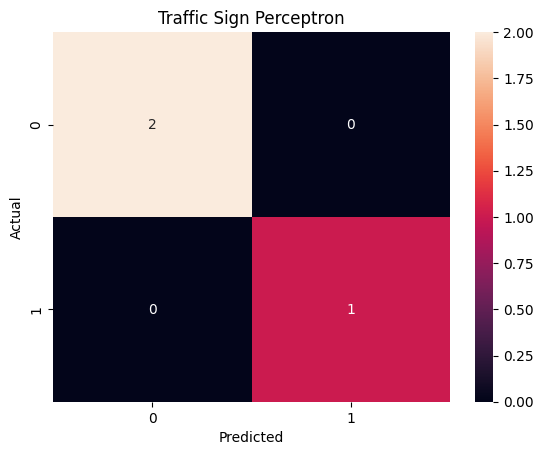

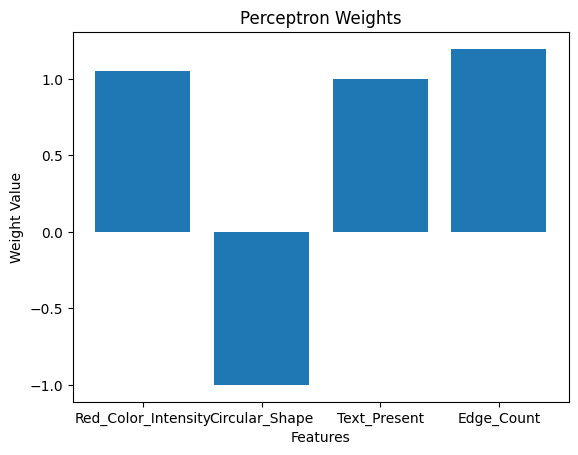

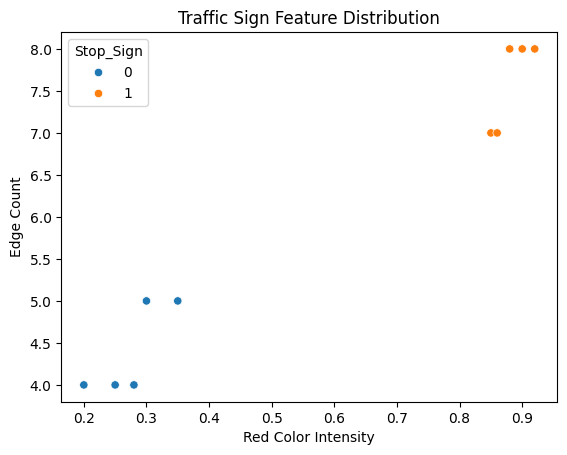

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


data = pd.read_csv("DatasetCapstoneProject4.csv")


X = data.drop(['Sign_ID', 'Stop_Sign'], axis=1)
y = data['Stop_Sign']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)


model = Perceptron(max_iter=1000, random_state=42)


model.fit(X_train, y_train)


y_pred = model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
cm =confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))
     #confusion matrix
plt.figure()

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Traffic Sign Perceptron")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# plt.show()
    #perceptron  visualisation

weights = model.coef_[0]

features = X.columns

plt.figure()

plt.bar(features, weights)

plt.title("Perceptron Weights")
plt.xlabel("Features")
plt.ylabel("Weight Value")

# plt.show()
      #feature distribution ghraph

plt.figure()

sns.scatterplot(
    x=data['Red_Color_Intensity'],
    y=data['Edge_Count'],
    hue=data['Stop_Sign']
)

plt.title("Traffic Sign Feature Distribution")
plt.xlabel("Red Color Intensity")
plt.ylabel("Edge Count")

plt.show()